In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

Epoch 1/50
5/5 [==============================] - 7s 381ms/step - loss: 0.2036 - val_loss: 0.1888 - lr: 0.0010
Epoch 2/50
5/5 [==============================] - 0s 13ms/step - loss: 0.1226 - val_loss: 0.1115 - lr: 0.0010
Epoch 3/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0715 - val_loss: 0.0594 - lr: 0.0010
Epoch 4/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0411 - val_loss: 0.0226 - lr: 0.0010
Epoch 5/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0229 - val_loss: 0.0043 - lr: 0.0010
Epoch 6/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0162 - val_loss: 0.0033 - lr: 0.0010
Epoch 7/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0159 - val_loss: 0.0045 - lr: 0.0010
Epoch 8/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0138 - val_loss: 0.0053 - lr: 0.0010
Epoch 9/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0132 - val_loss: 0.0037 - lr: 0.0010
Epoch 10/

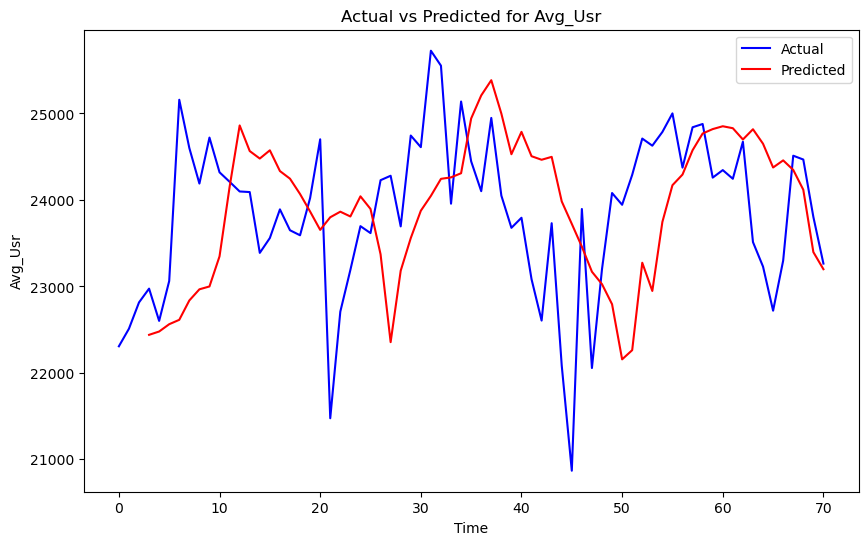

In [17]:
# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, :])
    return np.array(X), np.array(Y)

# Function to build and train LSTM model with given hyperparameters
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]), stateful=False))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)  # Adjust window size
look_back = 3
X_train, y_train = create_dataset(train, look_back=look_back)
X_test, y_test = create_dataset(test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Train the best model directly with known parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'

# Train model
model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE with normalized data
mse = mean_squared_error(y_test, test_predict)
print(f'MSE (normalized): {mse}')

# Invert the scaling (to return to original values)
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test)

# Shift the predictions back by window size (look_back) to align with actual values
test_predict_shifted = np.empty_like(y_test)
test_predict_shifted[:] = np.nan
test_predict_shifted[look_back:] = test_predict[:-look_back]

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(test_predict_shifted, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for {feature}')
plt.xlabel('Time')
plt.ylabel(f'{feature}')
plt.legend()
plt.show()

In [19]:
# Invert the scaling (to return to original values)
test_predict = scaler.inverse_transform(test_predict)
y_test = scaler.inverse_transform(y_test)

# Shift the predictions back by window size (look_back) to align with actual values
test_predict_shifted = np.empty_like(y_test)
test_predict_shifted[:] = np.nan
test_predict_shifted[:-look_back] = test_predict[look_back:]

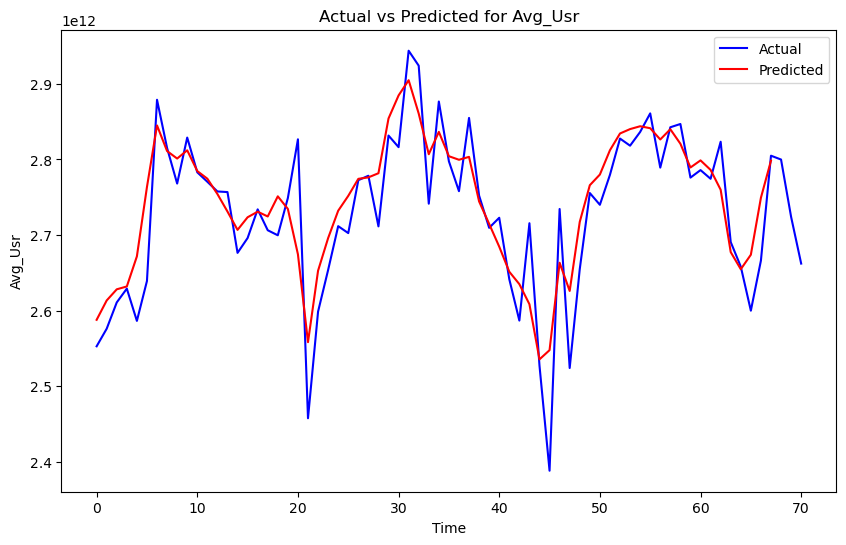

In [20]:
# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(test_predict_shifted, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for {feature}')
plt.xlabel('Time')
plt.ylabel(f'{feature}')
plt.legend()
plt.show()

In [21]:
# Calculate MSE with normalized data
mse = mean_squared_error(y_test, test_predict)
print(f'MSE (normalized): {mse}')


MSE (normalized): 8.791590772908366e+21


In [22]:
# Calculate MSE with normalized data
mse = mean_squared_error(y_test, test_predict_shifted)
print(f'MSE (normalized): {mse}')


ValueError: Input contains NaN.